# 1.2 — The curve and its strips

> *"A season is not a contract. It is twelve promises wearing one price."*

## The problem

Chapter 1.1 left us with a quarter (Q1-27) that we split into three equal pieces and a nagging feeling
that this was wrong. It was. Meanwhile the desk's screens show one price for **Win-26**, one for
**Cal-27**, one for **Q2-27** — and yet delivery happens month by month. Two questions:

1. How do strip prices relate to monthly prices — and can I *decompose* a strip exposure into months
   without error?
2. What shape does the whole curve have, and **why**? (If you do not know why winter is expensive you
   will not know when the shape is about to change under your hedge.)

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.contracts import *
from gashedge.market_data import synthetic_forward_curve, strip_table, monthly_price_dict, SEASONAL_FACTOR
from gashedge.hedging import strip_to_monthly_exposure
from gashedge.plotting import plot_curve, plot_curve_with_strips
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch1.2")
log.info("Environment ready")

2026-09-13 16:46:50.567 | INFO    | ch1.2 | Environment ready


## 1. A synthetic, but honest, curve

We do not have live data in this environment, so `market_data.synthetic_forward_curve` builds a
**stylised** 36-month TTF curve:

$$
P_{y,m} = L \cdot s(m) \cdot (1+g)^{\tau/12} \cdot \varepsilon
\tag{1.4}
$$

with level $L$, a seasonal multiplier $s(m)$ (winter ≈ +12 %, summer ≈ −8 %), a gentle annual drift $g$
(negative = backwardation), and a tiny noise term $\varepsilon$ so months are not perfectly smooth.
Every number is a placeholder for your own data feed — the *shape* is what we are studying.

2026-09-13 16:46:50.573 | INFO    | gashedge.market_data | Synthetic TTF curve as of 2026-09-14: 36 months, front=32.64, level=32.0


,tenor,symbol,hours,price
0,1,TFMV26,745,32.640
1,2,TFMX26,720,34.165
2,3,TFMZ26,744,35.875
3,4,TFMF27,744,35.350
4,5,TFMG27,672,34.661
5,6,TFMH27,743,32.276
6,7,TFMJ27,720,29.479
7,8,TFMK27,744,28.902


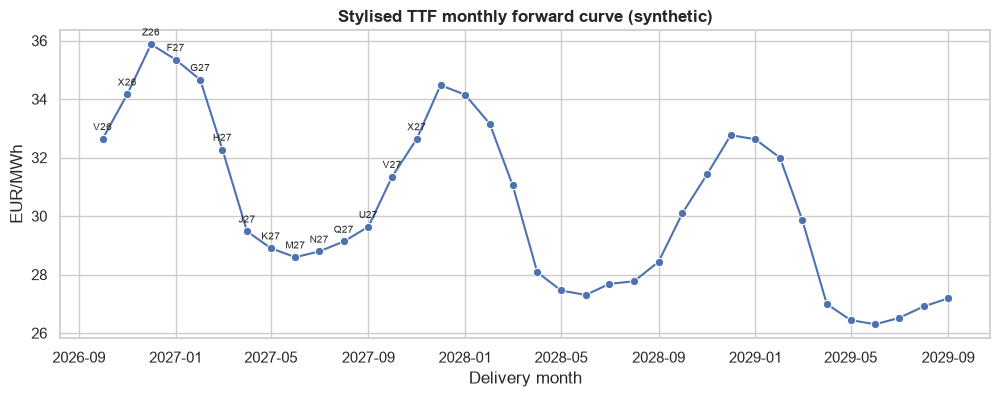

In [2]:
AS_OF = date(2026, 9, 14)
curve = synthetic_forward_curve(AS_OF, n_months=36, level=32.0, annual_drift=-0.04)
fig, ax = plt.subplots(figsize=(12, 4))
plot_curve(curve, title="Stylised TTF monthly forward curve (synthetic)", ax=ax)
for r in curve.head(14).itertuples():
    ax.text(r.delivery_start, r.price + 0.3, r.symbol[3:], fontsize=7, ha="center")
curve[["tenor", "symbol", "hours", "price"]].head(8)

## 2. Strip prices are hours-weighted averages — derived, not assumed

One lot of a strip covering months $m = 1..n$ delivers 1 MW in every hour of every one of those months.
Its total energy is $\sum_i H_i$ MWh and its total value must equal the value of the monthly legs, or
there is a free lunch:

$$
P_{\text{strip}} \sum_i H_i \;=\; \sum_i P_i H_i
\quad\Longrightarrow\quad
P_{\text{strip}} \;=\; \frac{\sum_i H_i P_i}{\sum_i H_i}
\tag{1.5}
$$

This is **not** the simple average of monthly prices. February has 672 hours, January 744; the winter
months with the highest prices also happen to have the most hours, so the equal-weighted average is
biased. On a €35 curve the bias is a few cents per MWh — but multiply by a 4,392-hour season and 50 lots,
and you have paid for a nice dinner without noticing.

In [3]:
prices = monthly_price_dict(curve)
strips = strip_table(curve)
strips["equal_weight_avg"] = strips.months.apply(lambda ms: np.mean([prices[m] for m in ms]))
strips["bias_cents"] = 100 * (strips.equal_weight_avg - strips.price)
log.info("Largest equal-weighting bias: %.1f cents/MWh (%s)", strips.bias_cents.abs().max(),
         strips.loc[strips.bias_cents.abs().idxmax(), "strip"])
strips[["strip", "kind", "n_months", "hours", "price", "equal_weight_avg", "bias_cents"]].head(12)

2026-09-13 16:46:50.700 | INFO    | ch1.2 | Largest equal-weighting bias: 1.8 cents/MWh (Q1-27)


,strip,kind,n_months,hours,price,equal_weight_avg,bias_cents
0,Q4-26,Q,3,2209,34.227,34.226667,-0.033333
1,Win-26,WIN,6,4368,34.153,34.161167,0.816667
2,Q1-27,Q,3,2159,34.078,34.095667,1.766667
3,Cal-27,CAL,12,8760,31.258,31.273000,1.500000
4,Q2-27,Q,3,2184,28.990,28.991333,0.133333
5,Sum-27,SUM,6,4392,29.086,29.088333,0.233333
6,Q3-27,Q,3,2208,29.180,29.185333,0.533333
7,Q4-27,Q,3,2209,32.821,32.819667,-0.133333
8,Win-27,WIN,6,4392,32.800,32.803167,0.316667
9,Cal-28,CAL,12,8784,29.943,29.948333,0.533333


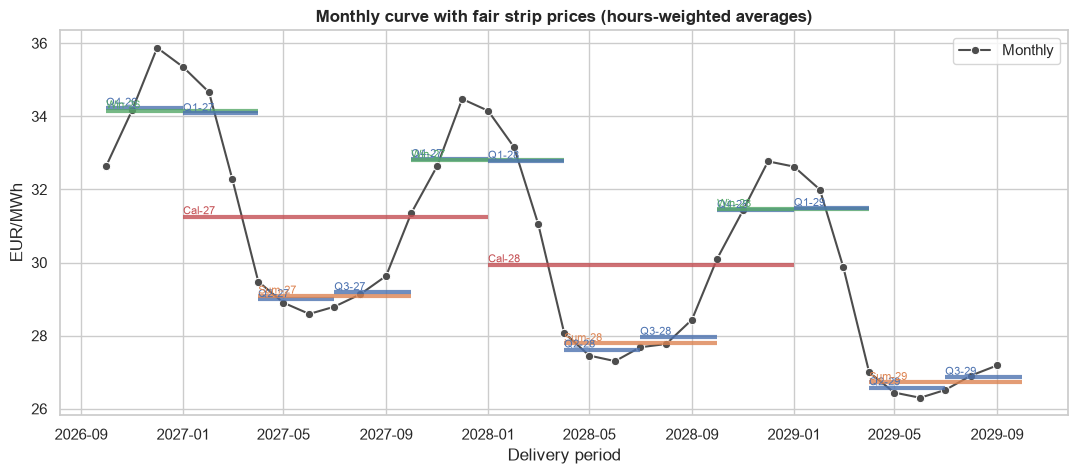

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_curve_with_strips(curve, strips, ax=ax);

## 3. Decomposing a strip exposure into months

The inverse operation is what the hedging engine does hundreds of times a day. A position of $q$ lots
in a strip is a position of **$q$ lots in each constituent month** — in MW terms it is flat, in MWh
terms it is $q \cdot H_i$ per month. So the Q1-27 line from the risk report (−9,800 MWh) must first be
turned back into MW:

$$
q_{\text{MW}} = \frac{Q_{\text{MWh}}}{\sum_i H_i}, \qquad Q_i = q_{\text{MW}} H_i
\tag{1.6}
$$

In [5]:
q1_months = quarter_months(2027, 1)
total_hours = sum(delivery_hours(y, m) for y, m in q1_months)
q_mw = -9_800 / total_hours
decomposed = strip_to_monthly_exposure(q_mw, q1_months)
decomposed["naive_equal_split"] = -9_800 / 3
decomposed["error_mwh"] = decomposed.naive_equal_split - decomposed.mwh
log.info("Q1-27 of -9,800 MWh is %.3f MW; naive equal split mis-states Feb by %.0f MWh", q_mw,
         decomposed.error_mwh.iloc[1])
decomposed

2026-09-13 16:46:50.847 | INFO    | ch1.2 | Q1-27 of -9,800 MWh is -4.539 MW; naive equal split mis-states Feb by -216 MWh


,year,month,symbol,hours,mwh,naive_equal_split,error_mwh
0,2027,1,TFMF27,744,-3377.119037,-3266.666667,110.452370
1,2027,2,TFMG27,672,-3050.301065,-3266.666667,-216.365601
2,2027,3,TFMH27,743,-3372.579898,-3266.666667,105.913231


The equal split over-hedges February by ~100 MWh and under-hedges January and March. Individually tiny.
Systematically, across a book of hundreds of strips, it is a bias — and biases, unlike noise, do not
average out.

## 4. Why does the curve have this shape? Storage economics in one inequality

The winter premium is not a mood. Gas can be **stored** (in depleted fields, salt caverns, aquifers), and
storage creates a no-arbitrage *upper bound* on the winter–summer spread. Suppose you can buy summer gas
at $P_S$, inject it, pay storage cost $c$ (capacity, injection, withdrawal, fuel gas) and financing at
rate $r$ for $\tau$ years, and sell it forward for winter at $P_W$. If

$$
P_W \;>\; P_S\,(1 + r\tau) + c
\tag{1.7}
$$

everyone with a storage contract does exactly that, and sells $P_W$ until the inequality closes. So
**the winter–summer spread is capped by the cost of carry**, and in normal years it trades close to it
(storage is scarce, the cap binds). There is *no symmetric lower bound*: nobody can borrow gas from
February to sell in August. Spreads can therefore collapse or invert — as they did in spring 2022 when
the market paid a fortune for *prompt* gas to fill storage before the winter, pushing near months far
above later ones (steep backwardation).

This asymmetry is the first structural fact a hedger needs: **a seasonal spread hedge behaves like a
short option** — bounded profit if the cap binds, unbounded pain if the curve inverts. We will meet its
cousin, the *roll yield*, in Chapter 2.4.

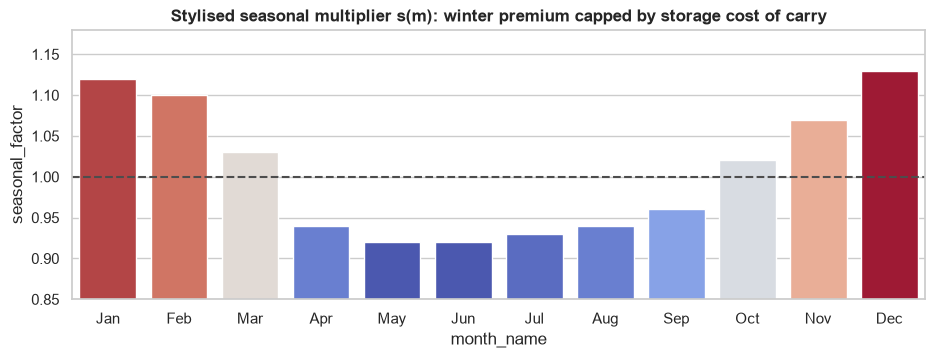

In [6]:
seasonal = pd.Series(SEASONAL_FACTOR, name="seasonal_factor").rename_axis("month").reset_index()
seasonal["month_name"] = pd.to_datetime(seasonal.month, format="%m").dt.strftime("%b")
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.barplot(data=seasonal, x="month_name", y="seasonal_factor", hue="seasonal_factor", palette="coolwarm", legend=False, ax=ax)
ax.axhline(1.0, color="0.3", ls="--"); ax.set_ylim(0.85, 1.18)
ax.set_title("Stylised seasonal multiplier s(m): winter premium capped by storage cost of carry");

## 5. Contango, backwardation, and what they cost a hedger

* **Contango**: later months more expensive than nearer ones. Classic in oversupplied markets with
  storage available; carrying gas forward "earns" the spread.
* **Backwardation**: nearer months more expensive. Typical when the prompt is tight (cold snap, outage,
  2022 storage panic).

The synthetic curve has $g = -4\%$ per year on top of seasonality, so it is mildly backwardated
*through the seasons*. Let us check by comparing the calendar strips, which strip seasonality out:

In [7]:
cals = strips[strips.kind == "CAL"][["strip", "price", "hours"]].reset_index(drop=True)
cals["yoy_change_pct"] = 100 * cals.price.pct_change()
log.info("Cal strips: %s", cals[["strip", "price"]].to_dict("records"))
cals

2026-09-13 16:46:50.950 | INFO    | ch1.2 | Cal strips: [{'strip': 'Cal-27', 'price': 31.258}, {'strip': 'Cal-28', 'price': 29.943}]


,strip,price,hours,yoy_change_pct
0,Cal-27,31.258,8760,NaN
1,Cal-28,29.943,8784,-4.206923


## 6. Where this leaves us

We can now (a) price any strip from months, (b) decompose any strip into months exactly, and (c) explain
the curve's shape from storage economics. The whole book — months, quarters, seasons, calendars, across
hubs — can be flattened into a single **monthly MWh ladder**. That ladder is the object every later
chapter operates on.

**Pitfall that leads to the next chapter:** equation (1.5) assumes you *could* trade every month at its
fair price. On a real screen, month 9 might show two lots on the bid and a spread ten times wider than
the front. The fair curve and the *tradeable* curve are different objects, and the difference is the
subject of Chapter 1.3.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Monthly prices: Jan-27 = 40.00, Feb-27 = 39.00, Mar-27 = 36.00 EUR/MWh (744, 672, 743 hours). Compute the fair Q1-27 price and the equal-weighted average. Which is higher and why?

<details><summary><i>Answer 1</i></summary>

Fair (hours-weighted, eq. 1.5): $(744\cdot40 + 672\cdot39 + 743\cdot36)/2159 = 82{,}716/2159 = \mathbf{38.312}$. Equal-weighted: $(40+39+36)/3 = 38.333$. The equal-weighted number is **2.1 cents higher** because it over-weights February — the short month — which here is the *second most expensive*, and under-weights March, the cheap long month. Whether the bias is up or down depends on how prices line up with hours; the point is that it is not zero.

</details>

**Q2.** A desk is long 30 lots of Win-26 (Oct-26…Mar-27) and short 30 lots of Q4-26 and 30 lots of Q1-27. In MWh, what is the net position per month? What if instead they were short 60 lots of Q1-27 only?

<details><summary><i>Answer 2</i></summary>

First case: **flat in every month** — Win = Q4 + Q1 lot-for-lot, because each is 1 MW in every hour of its months. Second case: long 30 MW in Oct, Nov, Dec (= +30×745, +30×720, +30×744 MWh) and short 30 MW in Jan, Feb, Mar (= −30×744, −30×672, −30×743 MWh). Net MWh is $30\times(2209-2159) = +1{,}500$ MWh, but that number is almost meaningless: the position is a **calendar spread** (long Q4 / short Q1) whose risk is the Q4–Q1 spread, not the outright level.

</details>

**Q3.** Summer gas is 30.00, storage all-in cost is 3.50 EUR/MWh, and financing for six months is 4 % p.a. What is the maximum arbitrage-free Winter price? If winter trades at 36.00, describe the trade and its risks.

<details><summary><i>Answer 3</i></summary>

Upper bound (eq. 1.7): $30 \times (1 + 0.04 \times 0.5) + 3.50 = 30.60 + 3.50 = \mathbf{34.10}$. At 36.00 the spread is 1.90 above the bound: buy summer, sell winter, book storage, inject, withdraw — locking ~1.90/MWh. Risks: storage capacity may not be available at 3.50 (the *marginal* storage cost is what caps the spread, and it rises as capacity fills); injection/withdrawal profiles constrain timing; both legs must be executed together or you carry outright risk between the fills.

</details>

**Q4.** Why is there no arbitrage that puts a **floor** under the winter–summer spread, and what does that imply about the P&L distribution of someone who is *long winter / short summer* as a hedge?

<details><summary><i>Answer 4</i></summary>

The reverse trade would require borrowing gas from the future (withdrawing in summer what you inject in winter) — physically impossible, since storage only moves gas forward in time. So the spread can go to zero or negative with nothing to stop it; only the *upper* side is capped. A long-winter/short-summer position therefore has a bounded upside (the spread cannot exceed cost of carry for long) and a large, unbounded downside — the payoff profile of a *short option*, and it must be risk-managed as one (Chapter 3.4 stress tests).

</details>


---
◀ [Previous](01_anatomy_of_a_gas_future.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](03_liquidity_profile.ipynb)